# OISST v2.1 파일 구조 탐색

- NaN % : 33.33815586419753 %, 육지가 대강 30%니까 결측이 거의 없다고 판단할 수 있었음.

In [1]:
import xarray as xr
import numpy as np
from pathlib import Path

DATA_DIR = Path("../data/raw/oisst_v21/daily")
sample_file = DATA_DIR / "oisst-avhrr-v02r01.19930101.nc"

In [2]:
ds = xr.open_dataset(sample_file)
ds

# time: 1, zlev: 1, lat: 720, lon: 1440
# data variables : anom, err, ice, sst

<xarray.Dataset> Size: 17MB
Dimensions:  (time: 1, zlev: 1, lat: 720, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
  * time     (time) datetime64[ns] 8B 1993-01-01T12:00:00
  * zlev     (zlev) float32 4B 0.0
Data variables:
    anom     (time, zlev, lat, lon) float32 4MB ...
    err      (time, zlev, lat, lon) float32 4MB ...
    ice      (time, zlev, lat, lon) float32 4MB ...
    sst      (time, zlev, lat, lon) float32 4MB ...
Attributes: (12/37)
    title:                      NOAA/NCEI 1/4 Degree Daily Optimum Interpolat...
    source:                     ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pathfin...
    id:                         oisst-avhrr-v02r01.19930101.nc
    naming_authority:           gov.noaa.ncei
    summary:                    NOAAs 1/4-degree Daily Optimum Interpolation ...
    cdm_data_type:              Grid
    ...                         ...
    metadata_link:              https://doi.org/10.25921/RE9P-PT57
    ncei_template_version:      NCEI_NetCDF_Grid_Template_v2.0
    comment:                    Data was converted from NetCDF-3 to NetCDF-4 ...
    sensor:                     Thermometer, AVHRR
    Conventions:                CF-1.6, ACDD-1.3
    references:                 Reynolds, et al.(2007) Daily High-Resolution-...

In [3]:
print("=== Dimensions ===")
for dim, size in ds.dims.items():
    print(f"  {dim}: {size}")

=== Dimensions ===
  time: 1
  zlev: 1
  lat: 720
  lon: 1440


C:\Users\dnjst\AppData\Local\Temp\ipykernel_26380\2975319377.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim, size in ds.dims.items():


In [4]:
print("=== Variables ===")
for var in ds.data_vars:
    v = ds[var]
    print(f"\n[{var}]")
    print(f"  dims  : {v.dims}")
    print(f"  shape : {v.shape}")
    print(f"  dtype : {v.dtype}")
    print(f"  attrs : {dict(v.attrs)}")

=== Variables ===

[anom]
  dims  : ('time', 'zlev', 'lat', 'lon')
  shape : (1, 1, 720, 1440)
  dtype : float32
  attrs : {'long_name': 'Daily sea surface temperature anomalies', 'valid_min': np.int16(-1200), 'valid_max': np.int16(1200), 'units': 'Celsius'}

[err]
  dims  : ('time', 'zlev', 'lat', 'lon')
  shape : (1, 1, 720, 1440)
  dtype : float32
  attrs : {'long_name': 'Estimated error standard deviation of analysed_sst', 'units': 'Celsius', 'valid_min': np.int16(0), 'valid_max': np.int16(1000)}

[ice]
  dims  : ('time', 'zlev', 'lat', 'lon')
  shape : (1, 1, 720, 1440)
  dtype : float32
  attrs : {'long_name': 'Sea ice concentration', 'units': '%', 'valid_min': np.int16(0), 'valid_max': np.int16(100)}

[sst]
  dims  : ('time', 'zlev', 'lat', 'lon')
  shape : (1, 1, 720, 1440)
  dtype : float32
  attrs : {'long_name': 'Daily sea surface temperature', 'units': 'Celsius', 'valid_min': np.int16(-300), 'valid_max': np.int16(4500)}


In [5]:
print("=== Coordinates ===")
for coord in ds.coords:
    c = ds.coords[coord]
    print(f"\n[{coord}]")
    print(f"  values: {c.values}" if c.size <= 5 else
          f"  range : {float(c.min().values):.4f} ~ {float(c.max().values):.4f}  (n={c.size})")

=== Coordinates ===

[lat]
  range : -89.8750 ~ 89.8750  (n=720)

[lon]
  range : 0.1250 ~ 359.8750  (n=1440)

[time]
  values: ['1993-01-01T12:00:00.000000000']

[zlev]
  values: [0.]


In [7]:
sst_var = "sst" 
sst = ds[sst_var].squeeze()   # time, zlev 등 길이-1 차원 제거
print("shape :", sst.shape)
print("min   :", float(sst.min()))
print("max   :", float(sst.max()))
print("mean  :", float(sst.mean()))
print("NaN % :", float(sst.isnull().mean()) * 100, "%")

shape : (720, 1440)
min   : -1.7999999523162842
max   : 31.85999870300293
mean  : 13.373156547546387
NaN % : 33.33815586419753 %


In [8]:
print("=== Global Attributes ===")
for k, v in ds.attrs.items():
    print(f"  {k}: {v}")

=== Global Attributes ===
  title: NOAA/NCEI 1/4 Degree Daily Optimum Interpolation Sea Surface Temperature (OISST) Analysis, Version 2.1 - Final
  source: ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pathfinder_AVHRR, Navy_AVHRR
  id: oisst-avhrr-v02r01.19930101.nc
  naming_authority: gov.noaa.ncei
  summary: NOAAs 1/4-degree Daily Optimum Interpolation Sea Surface Temperature (OISST) (sometimes referred to as Reynolds SST, which however also refers to earlier products at different resolution), currently available as version v02r01, is created by interpolating and extrapolating SST observations from different sources, resulting in a smoothed complete field. The sources of data are satellite (AVHRR) and in situ platforms (i.e., ships and buoys), and the specific datasets employed may change over time. At the marginal ice zone, sea ice concentrations are used to generate proxy SSTs.  A preliminary version of this file is produced in near-real time (1-day latency), and then replaced with a fina

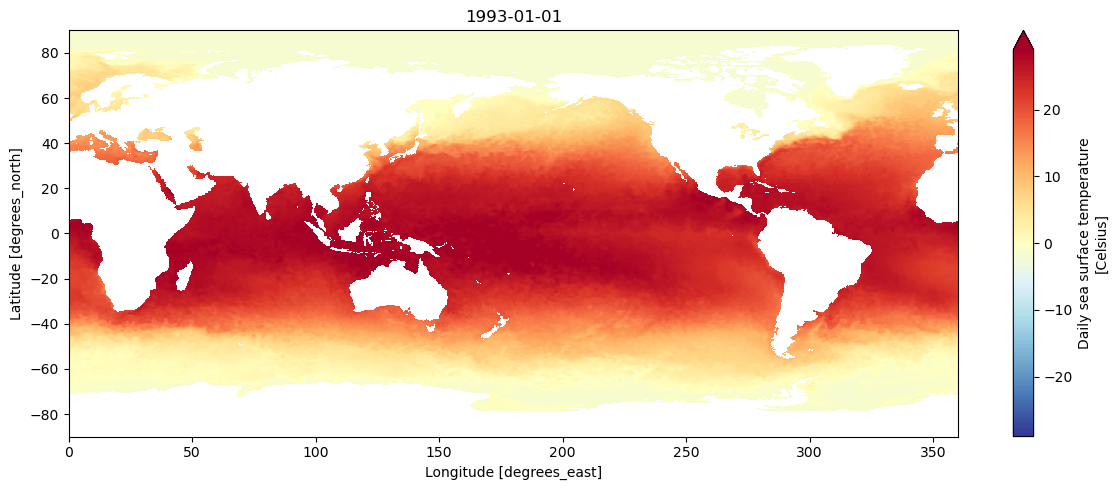

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
sst.plot(ax=ax, cmap="RdYlBu_r", robust=True)
ax.set_title("1993-01-01")
plt.tight_layout()
plt.show()